In [1]:
from pathlib import Path
#from battle_parser import Battle
from battle import Battle
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

replay_dir = Path(
    "/Users/marznewman/erdoswork/summer26-pokemon-battle-predictor/data/replays/gen9-randombattle"
)

files = sorted(replay_dir.glob("*.json"))

battle = Battle(files[0])

ALL_TYPES = [
    "Normal",
    "Fire",
    "Water",
    "Electric",
    "Grass",
    "Ice",
    "Fighting",
    "Poison",
    "Ground",
    "Flying",
    "Psychic",
    "Bug",
    "Rock",
    "Ghost",
    "Dragon",
    "Dark",
    "Steel",
    "Fairy"
]

In [2]:
def get_switch_stats(battle):

    ################### Switching ###################
    # Ignore the first "switch" that is actually just the lead pokemon
    p1_switches = -1
    p2_switches = -1

    p1_seen_move = False
    p2_seen_move = False

    p1_switched_early = 0
    p2_switched_early = 0

    # Flag that says whether the pokemon has fainted and needs replacement
    p1_needs_replacement = False
    p2_needs_replacement = False

    turns = 0

    for line in battle.log.split("\n"):
        #print(line)
        # Trying to ignore switches caused by fainting
        if line.startswith("|faint|"):
            if "|p1" in line:
                p1_needs_replacement = True

            elif "|p2" in line:
                p2_needs_replacement = True

        # increment nummber of turns
        if line.startswith("|turn|"):
            turns = int(line.split("|")[2])

        fields = line.split("|")

        if len(fields) < 3:
            continue

        if line.startswith("|move|"):
            #print(line)

            slot = fields[2]

            if slot.startswith("p1"):
                p1_seen_move = True

            elif slot.startswith("p2"):
                p2_seen_move = True
                
        elif line.startswith("|switch|"):

            slot = fields[2]

            if slot.startswith("p1"):

                if not p1_needs_replacement:
                    p1_switches += 1

                p1_needs_replacement = False

                if not p1_seen_move and p1_switches > 0:
                    p1_switched_early = 1

            elif slot.startswith("p2"):

                if not p2_needs_replacement:
                    p2_switches += 1

                p2_needs_replacement = False

                if not p2_seen_move and p2_switches > 0:
                    p2_switched_early = 1
                    
    return {
        "turns": turns,
        "p1_switches": p1_switches,
        "p2_switches": p2_switches,
        "p1_switched_early": p1_switched_early,
        "p2_switched_early": p2_switched_early,
    }


def team_features(team):

    total_bst = 0

    attacks = []
    speeds = []

    all_types = set()

    for pokemon in team.values():

        stats = pokemon["stats"]

        bst = (
            stats["hp"]
            + stats["atk"]
            + stats["def"]
            + stats["spa"]
            + stats["spd"]
            + stats["spe"]
        )

        total_bst += bst

        attacks.append(stats["atk"])
        speeds.append(stats["spe"])

        for t in pokemon["types"]:
            all_types.add(t)

    return {
        "team_bst": total_bst,
        "avg_attack": sum(attacks) / len(attacks),
        "avg_speed": sum(speeds) / len(speeds),
        "type_diversity": len(all_types)
    }

In [3]:
switch_rows = []
stat_rows = []
player_rows = []

for file in files:

    try:
        battle = Battle(str(file))
    except Exception:
        continue

    stats = get_switch_stats(battle)

    switch_rows.append({
        "battle_id": battle.id,
        "winner": int(battle.winner.name == battle.p1.name),
        **stats
    })

    p1 = team_features(
        battle.teams_full[0]
    )

    p2 = team_features(
        battle.teams_full[1]
    )

    stat_rows.append({

        "battle_id": battle.id,

        "winner":
            int(battle.winner.side == 1),

        "p1_team_bst":
            p1["team_bst"],

        "p2_team_bst":
            p2["team_bst"],

        "bst_diff":
            p1["team_bst"] - p2["team_bst"],

        "p1_avg_speed":
            p1["avg_speed"],

        "p2_avg_speed":
            p2["avg_speed"],

        "speed_diff":
            p1["avg_speed"] - p2["avg_speed"],

        "p1_avg_attack":
            p1["avg_attack"],

        "p2_avg_attack":
            p2["avg_attack"],

        "attack_diff":
            p1["avg_attack"] - p2["avg_attack"],

        "p1_type_diversity":
            p1["type_diversity"],

        "p2_type_diversity":
            p2["type_diversity"],

        "type_diversity_diff":
            p1["type_diversity"]
            - p2["type_diversity"]
    })

    if not battle.rated:
        continue

    player_rows.append({
        "battle_id": battle.id,
        "side": 1,
        "elo": battle.p1.elo0,
        "turns": stats["turns"],
        "switches": stats["p1_switches"],
        "switch_rate": stats["p1_switches"] / max(stats["turns"], 1),
        "early_switch": stats["p1_switched_early"],
        "won": int(battle.winner.side == 1)
    })

    player_rows.append({
        "battle_id": battle.id,
        "side": 2,
        "elo": battle.p2.elo0,
        "turns": stats["turns"],
        "switches": stats["p2_switches"],
        "switch_rate": stats["p2_switches"] / max(stats["turns"], 1),
        "early_switch": stats["p2_switched_early"],
        "won": int(battle.winner.side == 2)
    })

switch_df = pd.DataFrame(switch_rows)
team_df = pd.DataFrame(stat_rows)
player_df = pd.DataFrame(player_rows)

#team_df.head()
player_df.head()

,battle_id,side,elo,turns,switches,switch_rate,early_switch,won
0,gen9randombattle-2631360263,1,1787,88,2,0.022727,0,0
1,gen9randombattle-2631360263,2,1837,88,23,0.261364,0,1
2,gen9randombattle-2631365384,1,1895,32,2,0.062500,0,1
3,gen9randombattle-2631365384,2,1946,32,4,0.125000,0,0
4,gen9randombattle-2631366366,1,1506,24,5,0.208333,1,0


In [4]:
print(switch_df.groupby(
    "p1_switched_early"
)["winner"].mean())

print(1 - switch_df.groupby(
    "p2_switched_early"
)["winner"].mean())

p1_switched_early
0    0.498966
1    0.438783
Name: winner, dtype: float64
p2_switched_early
0    0.532349
1    0.486200
Name: winner, dtype: float64


If Player 1 switched before moving, Player 2 is more likely to win.
If Player 2 switched before moving, Player 2 is more likely to win.
What

2920
2139


/var/folders/t3/c0ztmjln40s87sclht7wr1xr0000gn/T/ipykernel_26063/162906957.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("switch_rate_bin")["won"]


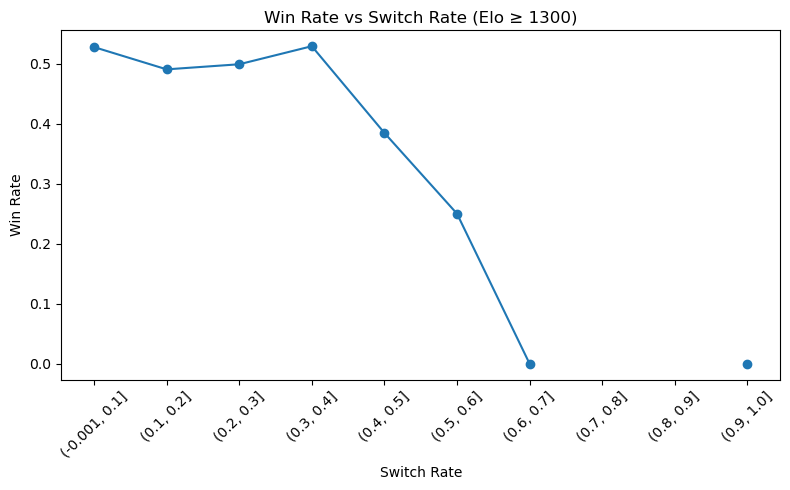

In [5]:
# Filter to players with elo > 1300 because switch rate levels out at this score
player_df_1300 = player_df[
    player_df["elo"] >= 1300
].copy()

print(len(player_df))
print(len(player_df_1300))

# Bin switch rates
player_df_1300["switch_rate_bin"] = pd.cut(
    player_df_1300["switch_rate"],
    bins=10
)

switchrate_bins = (
    player_df_1300
    .groupby("switch_rate_bin")["won"]
    .mean()
)

plt.figure(figsize=(8,5))

plt.plot(
    switchrate_bins.index.astype(str),
    switchrate_bins.values,
    marker="o"
)

plt.xticks(rotation=45)

plt.xlabel("Switch Rate")
plt.ylabel("Win Rate")
plt.title("Win Rate vs Switch Rate (Elo ≥ 1300)")

plt.tight_layout()
plt.show()

In [6]:
# Baseline model with elo
features = ["elo"]

X = player_df_1300[features]
y = player_df_1300["won"]

battle_ids = player_df_1300["battle_id"].unique()

train_battles, test_battles = train_test_split(
    battle_ids,
    test_size=0.2,
    random_state=0
)

train_df = player_df_1300[
    player_df_1300["battle_id"].isin(train_battles)
]

test_df = player_df_1300[
    player_df_1300["battle_id"].isin(test_battles)
]

X_train = train_df[features]
y_train = train_df["won"]

X_test = test_df[features]
y_test = test_df["won"]

baseline = LogisticRegression(
    max_iter=1000
)

baseline.fit(X_train, y_train)

pred = baseline.predict_proba(X_test)[:,1]

baseline_auc = roc_auc_score(y_test, pred)

print("Baseline AUC:", baseline_auc)

Baseline AUC: 0.49188199827734713


In [7]:
features = [
    "elo",
    "early_switch"
]

X_train = train_df[features]
X_test = test_df[features]

model = LogisticRegression(
    max_iter=1000
)

model.fit(X_train, y_train)

pred = model.predict_proba(X_test)[:,1]

model_auc = roc_auc_score(y_test, pred)

print("Model AUC:", model_auc)

Model AUC: 0.492355727820844


In [8]:
# Create a player-level version of team features
team_player_rows = []

for _, row in team_df.iterrows():

    # P1 perspective
    team_player_rows.append({
        "battle_id": row["battle_id"],
        "side": 1,
        "bst_diff": row["bst_diff"],
        "speed_diff": row["speed_diff"],
        "attack_diff": row["attack_diff"],
        "type_diversity_diff": row["type_diversity_diff"]
    })

    # P2 perspective (flip the signs)
    team_player_rows.append({
        "battle_id": row["battle_id"],
        "side": 2,
        "bst_diff": -row["bst_diff"],
        "speed_diff": -row["speed_diff"],
        "attack_diff": -row["attack_diff"],
        "type_diversity_diff": -row["type_diversity_diff"]
    })

team_player_df = pd.DataFrame(team_player_rows)

player_df = player_df.merge(
    team_player_df,
    on=["battle_id", "side"]
)

In [9]:
# Full Linear Regression model
features = [
    "elo",
    #"switch_rate",
    #"early_switch",
    "bst_diff",
    "speed_diff",
    #"attack_diff",
    "type_diversity_diff"
]

X = player_df[features]
y = player_df["won"]

battle_ids = player_df["battle_id"].unique()

train_battles, test_battles = train_test_split(
    battle_ids,
    test_size=0.2,
    random_state=0
)

train_df = player_df[
    player_df["battle_id"].isin(train_battles)
]

test_df = player_df[
    player_df["battle_id"].isin(test_battles)
]

X_train = train_df[features]
y_train = train_df["won"]

X_test = test_df[features]
y_test = test_df["won"]

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

pred = model.predict_proba(X_test)[:,1]

print("AUC =", roc_auc_score(y_test, pred))

AUC = 0.5528476261962846


In [10]:
# Decision Tree

tree = DecisionTreeClassifier(
    random_state=0,
    max_depth=5
)

tree.fit(X_train, y_train)

pred = tree.predict_proba(X_test)[:,1]

print(
    roc_auc_score(y_test, pred)
)

0.5399699756051791


In [11]:
# Random Forest

rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=4,
    min_samples_leaf=20,
    random_state=0
)

rf.fit(X_train, y_train)

pred = rf.predict_proba(X_test)[:,1]

print(
    roc_auc_score(y_test, pred)
)

0.5769609682867329


bst_diff               0.391355
elo                    0.273596
speed_diff             0.244803
type_diversity_diff    0.090245
dtype: float64


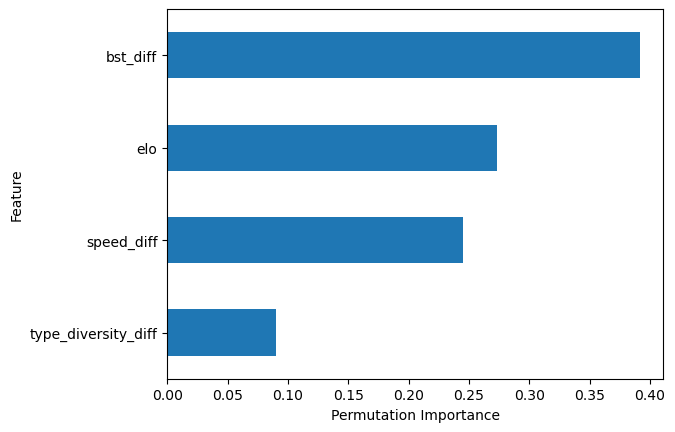

In [12]:
# Feature importance
importance = pd.Series(
    rf.feature_importances_,
    index=features
)

print(
    importance.sort_values(ascending=False)
)

importance.sort_values().plot.barh()

plt.xlabel("Permutation Importance")
plt.ylabel("Feature")

plt.show()

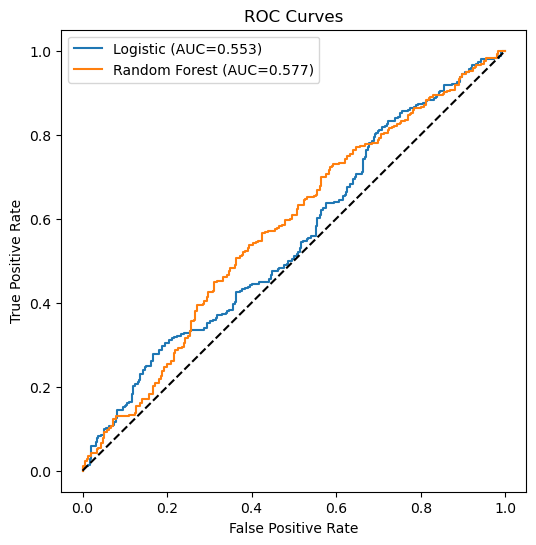

In [13]:
from sklearn.metrics import roc_curve

# Logistic regression
prob_lr = model.predict_proba(X_test)[:,1]
fpr_lr, tpr_lr, _ = roc_curve(y_test, prob_lr)

# Random forest
prob_rf = rf.predict_proba(X_test)[:,1]
fpr_rf, tpr_rf, _ = roc_curve(y_test, prob_rf)

plt.figure(figsize=(6,6))

plt.plot(
    fpr_lr,
    tpr_lr,
    label=f"Logistic (AUC={roc_auc_score(y_test, prob_lr):.3f})"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC={roc_auc_score(y_test, prob_rf):.3f})"
)

plt.plot([0,1],[0,1],"k--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()

plt.show()

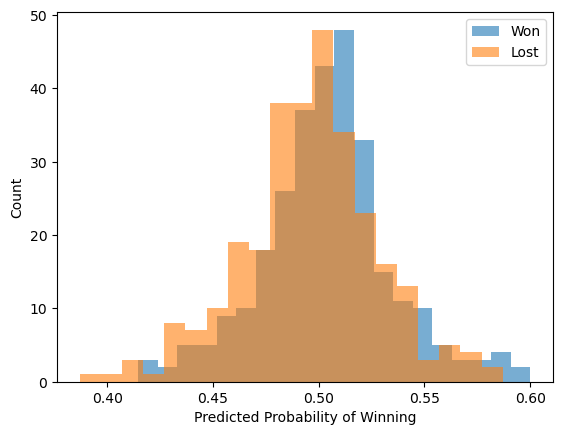

In [14]:
pred = rf.predict_proba(X_test)[:,1]

plt.hist(
    pred[y_test==1],
    bins=20,
    alpha=0.6,
    label="Won"
)

plt.hist(
    pred[y_test==0],
    bins=20,
    alpha=0.6,
    label="Lost"
)

plt.xlabel("Predicted Probability of Winning")
plt.ylabel("Count")

plt.legend()

plt.show()

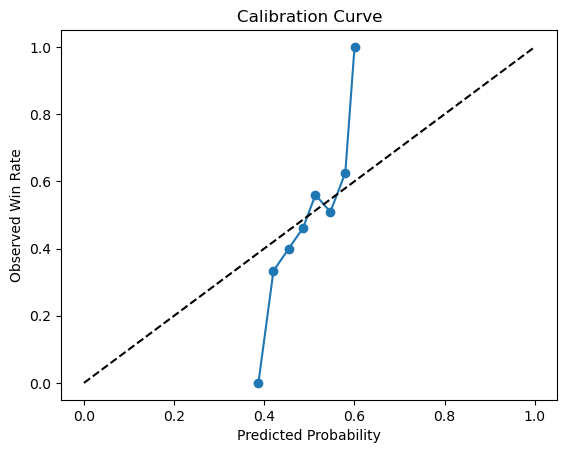

In [23]:
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(
    y_test,
    pred,
    n_bins=30
)

plt.plot(prob_pred, prob_true, marker="o")
plt.plot([0,1],[0,1],"k--")

plt.xlabel("Predicted Probability")
plt.ylabel("Observed Win Rate")
plt.title("Calibration Curve")

plt.show()

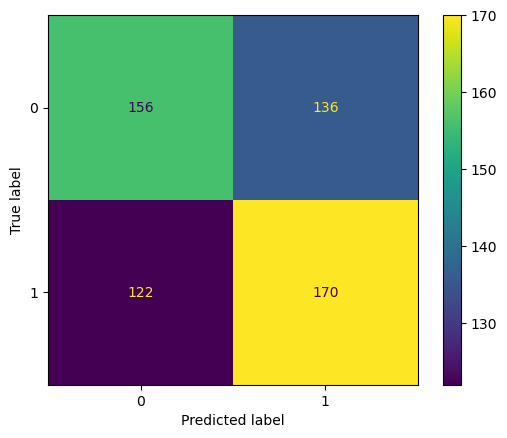

In [16]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    rf,
    X_test,
    y_test
)

plt.show()

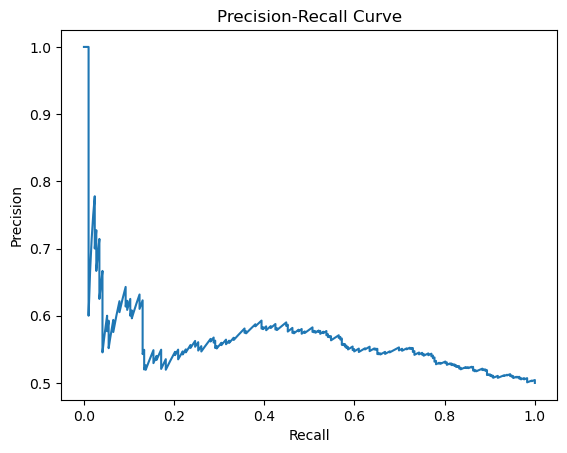

In [17]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(
    y_test,
    pred
)

plt.plot(recall, precision)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.show()

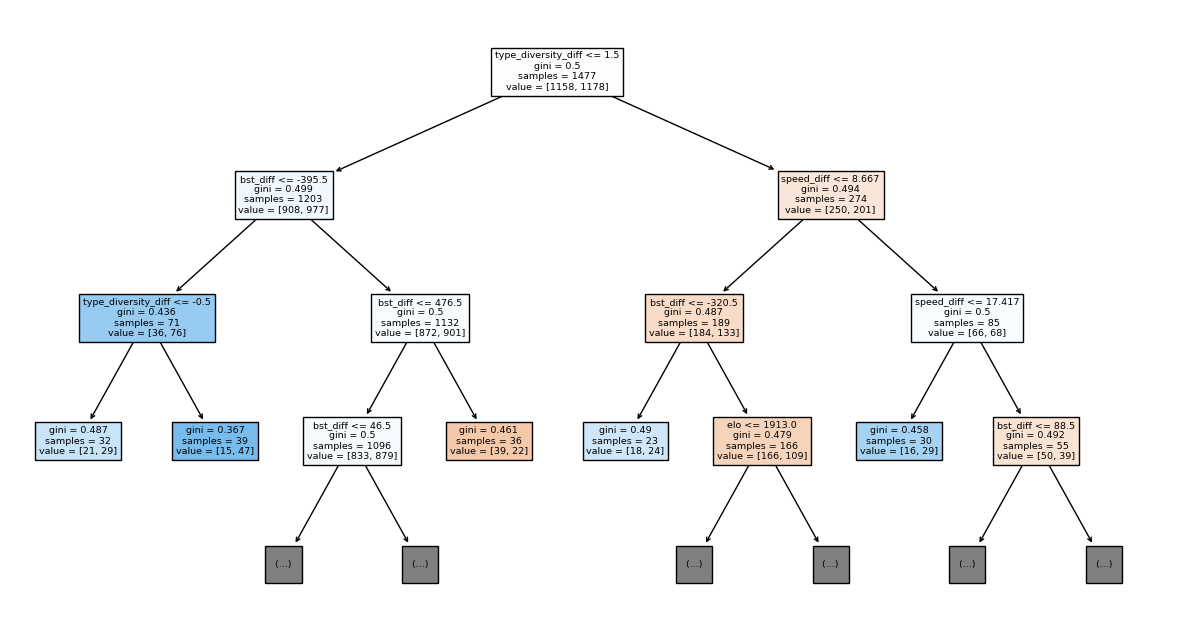

In [18]:
from sklearn.tree import plot_tree

plt.figure(figsize=(15,8))

plot_tree(
    rf.estimators_[0],
    feature_names=features,
    filled=True,
    max_depth=3
)

plt.show()

In [19]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    rf,
    X,
    y,
    cv=5,
    scoring="roc_auc"
)

print(scores)
print(scores.mean())
print(scores.std())

[0.50707215 0.56254691 0.53463361 0.54365266 0.5345867 ]
0.5364984049540251
0.01790387955196535


In [20]:
# Do a grid search for random forest parameters
from sklearn.model_selection import GridSearchCV

param_grid = {
    "max_depth": [4, 6, 8, 10],
    "min_samples_leaf": [5, 10, 20],
    "n_estimators": [200, 500, 800]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=0),
    param_grid,
    cv=5,
    scoring="roc_auc"
)

grid.fit(X, y)

print(grid.best_params_)
print(grid.best_score_)

KeyboardInterrupt: 